#**EVIDENCIA 4**

#**EMAX:**

José Emiliano Díaz Gutiérrez | A01711141

Ximena Cantera Reséndiz       | A01277310

Ma. Fernanda Barba De Los Santos  | A01657868


#**Importar librerías y documentos**

In [87]:
%pip install statsmodels
%pip install scrikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scrikit-learn (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for scrikit-learn


In [88]:
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Librerías para ANOVA Robusto
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_hc3
import warnings
warnings.filterwarnings('ignore')

# XGBOOST
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score

In [90]:
# Importar documentos
distribuidores = pd.read_excel("../data/ArchivosOriginales/Distribuidores_Todo.xlsx")
horas = pd.read_excel("../data/ArchivosOriginales/Horas 2024-2025.xlsx")
ruteo = pd.read_excel("../data/ArchivosOriginales/Indicadores de Ruteo.xlsx")
mantenimientos = pd.read_excel("../data/ArchivosOriginales/Mantenimientos 2024-2025.xlsx")
population = pd.read_excel("../data/ArchivosOriginales/PopulationView_2026.xlsx")
reporte = pd.read_excel("../data/ArchivosOriginales/Reporte_unidades_dia_anterior.xlsx", header=1)


In [91]:
distribuidores.columns

Index(['No.', 'Unidad', 'Distribuidor', 'Marca', 'Modelo', 'Estado', 'Ciudad',
       'Horas'],
      dtype='object')

In [92]:
horas.columns

Index(['Num', 'Distribuidor', 'IMEI', 'Alias', 'Marca', 'Modelo', 'Ciudad',
       'Estado', 'Latitud', 'Longitud', '2024-01', '2024-02', '2024-03',
       '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09',
       '2024-10', '2024-11', '2024-12'],
      dtype='object')

In [93]:
ruteo.columns

Index(['Division', 'Distancia del Dia', 'Distancia de Ruta',
       'Cumplimiento Salida (06:30:00)', '% Utilizacion', '% Visitas Plan',
       '% Visitas Clientes', 'Total Kilos'],
      dtype='object')

In [94]:
mantenimientos.columns

Index(['No', 'ALIAS', 'MARCA', 'MODELO', 'CONFIGURACION', 'NO SERIE',
       'DISTRIBUIDOR', 'SERVICIO', 'HRMTRO', 'ACTUAL', 'TIPO', 'FECHA', 'O.T.',
       'ESTATUS', 'Editar'],
      dtype='object')

In [95]:
population.columns

Index(['VIN (9 CHARACTERS)', 'VIN (17 CHARACTERS)', 'VIN', 'BRAND', 'TYPE',
       'PRODUCT', 'SERIES', 'MODEL', 'TECHNICAL TYPE', 'ICE CODE',
       'DEVICE SERIAL NUMBER', 'SEVERITY LEVEL', 'CONTEXT', 'DEALER',
       'DEALER NAME', 'DEALER CODE', 'COUNTRY OF COMPETENCE', 'LATITUDE',
       'LONGITUDE', 'LAST KNOWN POSITION (COUNTRY)', 'TELEMATICS BOX',
       'TELEMATICS BRAND', 'TELEMATICS TYPE', 'TELEMATICS MODEL', 'OWNER NAME',
       'ENGINE HOURS', 'LATEST COMMUNICATION DATE', 'BDE PROCESSED AT TIME',
       'LOWER PIN BREAK', 'UPPER PIN BREAK', 'MYFLEET DEALER',
       'MYFLEET DEALER NAME', 'EULA ACCEPTED', 'EULA DATE'],
      dtype='object')

In [96]:
reporte.columns

Index([                 'No',                'IMEI',               'Alias',
                     'Marca',              'Modelo',       'Configuracion',
                'Fecha Alta',           'No. Serie',        'Distribuidor',
                    'Ciudad',              'Estado',           'Horometro',
                  'Odometro',               'Total',            'Cerrados',
                   'C.Fuera',          'Pendientes',                    50,
                         300,                   600,                   900,
                        1200,                  1500,                  1800,
                        2100,                  2400,             'Cliente',
                  'Telefono',               'Email',             'Latitud',
                  'Longitud',                 'PEP',         'Combustible',
                 'Distancia',   'Vel. Maxima (kph)', 'Vel. Promedio (kph)',
        'T. Encendido (hrs)',    'T. Apagado (hrs)'],
      dtype='object')

#**Limpieza de datos**

**Nulos**

**Distribuidores**

In [97]:
distribuidores.isnull().sum()
#no hay nulos, no se borra nada

No.             0
Unidad          0
Distribuidor    0
Marca           0
Modelo          0
Estado          0
Ciudad          0
Horas           0
dtype: int64

In [98]:
distribuidores.duplicated().sum()
#no tiene duplicados

0

**Horas**

In [99]:
horas.isnull().sum()

Num                0
Distribuidor       0
IMEI               0
Alias              0
Marca             15
Modelo          6263
Ciudad            15
Estado          6263
Latitud           15
Longitud          15
2024-01            0
2024-02            0
2024-03            0
2024-04            0
2024-05            0
2024-06            0
2024-07            0
2024-08            0
2024-09            0
2024-10            0
2024-11            0
2024-12            0
dtype: int64

En esta base horas, las columnas más importantes son las de identificación y las columnas mensuales, porque sirven para observar el comportamiento mensual del equipo durante 2024 y 2025. Por lo que en esta base se busca analizar evolución mensual, actividad por equipo, comparativos entre años y concentración de actividad por región o distribuidor.

In [100]:
horas = horas.drop(columns=[
    'Num)',
    'Modelon',
    'Estado',
], errors='ignore')

En la base de datos de horas se eliminaron las columnas Num, Modelo y Estado, ya que no aportaban información relevante para el objetivo final del análisis.
La columna Num funciona únicamente como un consecutivo o índice interno, por lo que no representa una variable explicativa relacionada con el comportamiento operativo de las unidades. Por otro lado, las columnas Modelo y Estado presentaban una cantidad considerable de valores nulos, lo que podía afectar la calidad del análisis y generar ruido dentro del proceso de limpieza y modelado.

In [101]:
horas['Ciudad'] = horas['Ciudad'].fillna('Desconocido')
horas['Marca'] = horas['Marca'].fillna('Desconocido')
horas['Latitud'] = horas['Latitud'].fillna(0)
horas['Longitud'] = horas['Longitud'].fillna(0)

Se decidió rellenar la columna "Ciudad" con el valor `"Desconocido"`, ya que se trata de una variable categórica y este reemplazo permite conservar los registros sin eliminar información útil de las unidades. En el caso de "Latitud" y "Longitud", los valores faltantes se sustituyeron por 0, debido a que son variables numéricas y no conviene reemplazarlas con texto, ya que esto podría generar errores en análisis posteriores, visualizaciones o cálculos.

In [102]:
horas.duplicated().sum()
#no tiene duplicados

0

In [103]:
horas.isnull().sum()

Num                0
Distribuidor       0
IMEI               0
Alias              0
Marca              0
Modelo          6263
Ciudad             0
Latitud            0
Longitud           0
2024-01            0
2024-02            0
2024-03            0
2024-04            0
2024-05            0
2024-06            0
2024-07            0
2024-08            0
2024-09            0
2024-10            0
2024-11            0
2024-12            0
dtype: int64

**Ruteo**

In [104]:
ruteo.isnull().sum()

Division                           1
Distancia del Dia                  0
Distancia de Ruta                  0
Cumplimiento Salida (06:30:00)     0
% Utilizacion                      0
% Visitas Plan                     0
% Visitas Clientes                 0
Total Kilos                       35
dtype: int64

In [105]:
ruteo.duplicated().sum()

0

In [106]:
ruteo = ruteo.drop(columns=[
    'Cumplimiento Salida (06:30:00)',
    '% Utilizacion',
    '% Visitas Plan',
    '% Visitas Clientes',
    'Total Kilos'
], errors='ignore')

In [107]:
ruteo.columns

Index(['Division', 'Distancia del Dia', 'Distancia de Ruta'], dtype='object')

En la base de ruteo se revisó la existencia de registros duplicados mediante la función duplicated().sum(). El resultado fue 0, por lo que no se identificaron filas repetidas completas y no fue necesario eliminar duplicados. Posteriormente, se eliminaron las columnas Cumplimiento Salida (06:30:00), % Utilización, % Visitas Plan, % Visitas Clientes y Total Kilos, debido a que no contenían información útil para el análisis, ya que sus valores estaban en cero o como NA. Por esta razón, se conservaron únicamente las variables relevantes para el proyecto: División, Distancia del Día y Distancia de Ruta, las cuales permiten analizar el comportamiento operativo de ruteo por distribuidor.

**Mantenimiento**

In [108]:
mantenimientos.isnull().sum()

No               23904
ALIAS                0
MARCA                4
MODELO               4
CONFIGURACION        4
NO SERIE            38
DISTRIBUIDOR       303
SERVICIO             0
HRMTRO               0
ACTUAL               0
TIPO                 4
FECHA                0
O.T.             14420
ESTATUS              4
Editar           23904
dtype: int64

In [109]:
# Eliminar columnas que no aportan o tienen demasiados nulos
mantenimientos = mantenimientos.drop(columns=[
    'No',
    'Editar',
    'O.T.'
], errors='ignore')

# Rellenar valores nulos en columnas categóricas importantes
columnas_rellenar = [
    'MARCA',
    'MODELO',
    'CONFIGURACION',
    'NO SERIE',
    'DISTRIBUIDOR',
    'TIPO',
    'ESTATUS'
]

for col in columnas_rellenar:
    if col in mantenimientos.columns:
        mantenimientos[col] = mantenimientos[col].fillna('Desconocido')

# Verificar nulos restantes
mantenimientos.isnull().sum()

ALIAS            0
MARCA            0
MODELO           0
CONFIGURACION    0
NO SERIE         0
DISTRIBUIDOR     0
SERVICIO         0
HRMTRO           0
ACTUAL           0
TIPO             0
FECHA            0
ESTATUS          0
dtype: int64

Se eliminaron porque:

No tiene 23,904 nulos y normalmente es solo un consecutivo, entonces no aporta al modelo.

Editar también tiene 23,904 nulos y parece una columna de acción del sistema, no una variable analítica.

O.T. tiene 14,420 nulos. Aunque representa la orden de trabajo, tiene demasiados faltantes y no es tan útil para predecir riesgo o mantenimiento pendiente/fuera.

In [110]:
mantenimientos.duplicated().sum()

35

In [111]:
# Mostrar todas las filas duplicadas completas
duplicados_mantenimientos = mantenimientos[mantenimientos.duplicated(keep=False)]

duplicados_mantenimientos

,ALIAS,MARCA,MODELO,CONFIGURACION,NO SERIE,DISTRIBUIDOR,SERVICIO,HRMTRO,ACTUAL,TIPO,FECHA,ESTATUS
19841,862407063625549,NEW HOLLAND AG,6610S,2WD,S33254M-6099110,MADISA,12900,12860.0,13256,Preventivo,29/08/25 13:59,CerradaFuera
19842,862407063625549,NEW HOLLAND AG,6610S,2WD,S33254M-6099110,MADISA,12900,12860.0,13256,Preventivo,29/08/25 13:59,CerradaFuera
19939,TRACSA - S508004M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508004M-8095782,AGTRAC,3900,3860.0,4266,Preventivo,2025-01-09 13:58:00,Pendiente
19940,TRACSA - S508004M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508004M-8095782,AGTRAC,3900,3860.0,4266,Preventivo,2025-01-09 13:58:00,Pendiente
20370,862407061497149,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,NH11088M-002191675,ATN,1500,1460.0,2111,Preventivo,14/09/25 13:55,Pendiente
...,...,...,...,...,...,...,...,...,...,...,...,...
23657,MADISA-S402871M-8107456,NEW HOLLAND AG,7610S HERENCIA,2WD,S402871M-8107456,MADISA,1800,1760.0,1841,Preventivo,30/12/25 14:00,Pendiente
23804,862407061586479,NEW HOLLAND AG,7610S HERENCIA,LODERO,S509351M-8131368,ATC,1500,1500.0,1762,Preventivo,16/10/25 13:57,CerradaFuera
23805,862407061586479,NEW HOLLAND AG,7610S HERENCIA,LODERO,S509351M-8131368,ATC,1500,1500.0,1762,Preventivo,16/10/25 13:57,CerradaFuera
23894,DASSA-4100041M,NEW HOLLAND AG,TS6.120 ELITE,FWD 8X8 MS CABINA,4100041M-001871869,ARBSA,1500,1460.0,1698,Preventivo,2025-07-11 13:55:00,CerradaFuera


In [112]:
# Eliminar registros duplicados completos en la base de mantenimientos
mantenimientos = mantenimientos.drop_duplicates()

# Verificar que ya no haya duplicados
mantenimientos.duplicated().sum()

0

En la base de mantenimientos se identificaron 35 registros duplicados completos. Al revisar las filas duplicadas, se observó que contenían la misma información en las variables principales del servicio, como ALIAS, MARCA, MODELO, CONFIGURACION, NO SERIE, DISTRIBUIDOR, SERVICIO, HRMTRO, ACTUAL, TIPO, FECHA y ESTATUS. Por esta razón, se decidió eliminar los duplicados mediante drop_duplicates(), ya que mantenerlos podría inflar artificialmente la cantidad de servicios registrados y afectar el análisis de mantenimientos pendientes o fuera de tiempo.

**Population**

In [113]:
population.isnull().sum()

VIN (9 CHARACTERS)                21
VIN (17 CHARACTERS)              312
VIN                                0
BRAND                              0
TYPE                               0
PRODUCT                            0
SERIES                             0
MODEL                              0
TECHNICAL TYPE                     0
ICE CODE                           0
DEVICE SERIAL NUMBER               0
SEVERITY LEVEL                     0
CONTEXT                            0
DEALER                             0
DEALER NAME                      424
DEALER CODE                      284
COUNTRY OF COMPETENCE              0
LATITUDE                           0
LONGITUDE                          0
LAST KNOWN POSITION (COUNTRY)      0
TELEMATICS BOX                     0
TELEMATICS BRAND                   0
TELEMATICS TYPE                    0
TELEMATICS MODEL                   0
OWNER NAME                         0
ENGINE HOURS                       0
LATEST COMMUNICATION DATE          0
B

In [114]:
population = population.drop(columns=[
    'VIN (9 CHARACTERS)',
    'LOWER PIN BREAK',
    'UPPER PIN BREAK',
    'EULA DATE'
], errors='ignore')

Se eliminaron VIN (9 CHARACTERS) porque es una version parcial del VIN. Se guarda VIN 17 porque nos ayudará con severity level después.
LOWER PIN BREAK y UPPER PIN BREAK tienen bastantes nulos y no parecen variables centrales para el análisis de mantenimiento o aftermarket.
EULA DATE tiene muchos nulos y no aporta directamente a predecir mantenimiento pendiente/fuera.

In [115]:
columnas_desconocido = [
    'DEALER NAME',
    'DEALER CODE',
    'MYFLEET DEALER',
    'MYFLEET DEALER NAME',
    'EULA ACCEPTED'
]

for col in columnas_desconocido:
    if col in population.columns:
        population[col] = population[col].fillna('Desconocido')

Por otro lado, se conservaron variables como SEVERITY LEVEL, ENGINE HOURS, DEALER, DEALER NAME, LATITUDE, LONGITUDE, LATEST COMMUNICATION DATE y datos de telemática, ya que estas permiten conectar el estado operativo de la unidad con el riesgo de intervención técnica. Para las columnas categóricas con valores faltantes, como datos de dealer o aceptación de EULA, se reemplazaron los nulos por "Desconocido" con el fin de mantener los registros disponibles sin perder unidades relevantes para el análisis.

In [116]:
population.isnull().sum()

VIN (17 CHARACTERS)              312
VIN                                0
BRAND                              0
TYPE                               0
PRODUCT                            0
SERIES                             0
MODEL                              0
TECHNICAL TYPE                     0
ICE CODE                           0
DEVICE SERIAL NUMBER               0
SEVERITY LEVEL                     0
CONTEXT                            0
DEALER                             0
DEALER NAME                        0
DEALER CODE                        0
COUNTRY OF COMPETENCE              0
LATITUDE                           0
LONGITUDE                          0
LAST KNOWN POSITION (COUNTRY)      0
TELEMATICS BOX                     0
TELEMATICS BRAND                   0
TELEMATICS TYPE                    0
TELEMATICS MODEL                   0
OWNER NAME                         0
ENGINE HOURS                       0
LATEST COMMUNICATION DATE          0
BDE PROCESSED AT TIME              0
M

In [117]:
population.duplicated().sum()

50

In [118]:
duplicados_population = population[population.duplicated(keep=False)]

duplicados_population

,VIN (17 CHARACTERS),VIN,BRAND,TYPE,PRODUCT,SERIES,MODEL,TECHNICAL TYPE,ICE CODE,DEVICE SERIAL NUMBER,...,TELEMATICS BRAND,TELEMATICS TYPE,TELEMATICS MODEL,OWNER NAME,ENGINE HOURS,LATEST COMMUNICATION DATE,BDE PROCESSED AT TIME,MYFLEET DEALER,MYFLEET DEALER NAME,EULA ACCEPTED
29,JAFSV300HRM456279,JAFSV300HRM456279,CASE CONSTRUCTION,LIGHT EQUIPMENT,SKID STEER LOADERS,B Series Skid Steer Loaders,SV300B,550711208,E.S.64.009.014.002,1598-3C000D50,...,CC,SSL,SV300B (T3),POLLO INDUSTRIALIZADO DE MEXICO,1571,2026-02-09 12:03:56,2026-02-09 00:33:33,190-08B288A,Dimapesa Sa De Cv,Yes
30,JAFSV300HRM456279,JAFSV300HRM456279,CASE CONSTRUCTION,LIGHT EQUIPMENT,SKID STEER LOADERS,B Series Skid Steer Loaders,SV300B,550711208,E.S.64.009.014.002,1598-3C000D50,...,CC,SSL,SV300B (T3),POLLO INDUSTRIALIZADO DE MEXICO,1571,2026-02-09 12:03:56,2026-02-09 00:33:33,190-08B288A,Dimapesa Sa De Cv,Yes
41,JJGN58NRLPC787412,JJGN58NRLPC787412,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,1598-3C000A36,...,CC,TLB_US,580N (T3),MARIA ELSI CASANOVA ROJAS,3457,2026-02-09 12:59:54,2026-02-09 01:33:33,190-08B288A,Dimapesa Sa De Cv,Yes
42,JJGN58NRLPC787412,JJGN58NRLPC787412,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,1598-3C000A36,...,CC,TLB_US,580N (T3),MARIA ELSI CASANOVA ROJAS,3457,2026-02-09 12:59:54,2026-02-09 01:33:33,190-08B288A,Dimapesa Sa De Cv,Yes
43,JJGN58NRTPC787433,JJGN58NRTPC787433,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,1598-3C0009C9,...,CC,TLB_US,580N (T3),Johnson Controls,1903,2026-02-08 19:25:28,2026-02-09 00:33:33,190-08B288A,Dimapesa Sa De Cv,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,NKJ851NXJSKH46430,NKJ851NXJSKH46430,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,NX Series,851NX,675040251,E.S.65.022.004.003,1603-360029FA,...,CC,TLB_EU,851NX (Stage V),Jehlum Engineers & Construction Equipments,115,2026-02-07 20:38:42,2026-02-09 00:33:33,740-CH8599A,Jehlum Engineers & Construction Equipments,Desconocido
572,PRCY9000ERPA07217,PRCY9000ERPA07217,CASE IH,HARVESTING EQUIPMENT,SUGAR CANE,AUSTOFT 9000 Series,AUSTOFT 9000,579520033,A.J.17.004.001.034,540818555,...,CS,Sugar Cane Harvester,SWSN04,Inter Agrups,12,2026-02-05 12:37:10,2026-02-09 00:33:33,190-08B273A,Agrotractores Del Centro Sa De Cv,Desconocido
573,PRCY9000ERPA07217,PRCY9000ERPA07217,CASE IH,HARVESTING EQUIPMENT,SUGAR CANE,AUSTOFT 9000 Series,AUSTOFT 9000,579520033,A.J.17.004.001.034,540818555,...,CS,Sugar Cane Harvester,SWSN04,Inter Agrups,12,2026-02-05 12:37:10,2026-02-09 00:33:33,190-08B273A,Agrotractores Del Centro Sa De Cv,Desconocido
581,PRCY9900PPPA06591,PRCY9900PPPA06591,CASE IH,HARVESTING EQUIPMENT,SUGAR CANE,AUSTOFT 9000 Series,AUSTOFT 9900,579520036,A.J.17.004.002.030,531248282,...,CS,Sugar Cane Harvester,MY21,ASOCIACION DE CAÑEROS PROPIETARIOS Y EJIDATARIOS,5906,2026-02-09 11:53:09,2026-02-09 00:33:33,190-08B072A,Agro Equipos S.A. De C.V.,Yes


In [119]:
# Eliminar duplicados completos en Population
population = population.drop_duplicates()

# Verificar que ya no haya duplicados
population.duplicated().sum()

0

En la base Population se identificaron registros duplicados completos. Al revisar las filas, se observó que correspondían a unidades repetidas con la misma información en variables clave como VIN, BRAND, TYPE, MODEL, ICE CODE y DEVICE SERIAL NUMBER. Debido a que esta base representa equipos individuales con telemetría, mantener estos duplicados podría alterar el conteo real de unidades, la distribución por severidad y el análisis de horas de motor. Por esta razón, se eliminaron los duplicados completos mediante drop_duplicates().

**Reporte unidades día anterior**

In [120]:
reporte.isnull().sum()

No                         0
IMEI                       0
Alias                      0
Marca                    717
Modelo                   939
Configuracion           1416
Fecha Alta               642
No. Serie                710
Distribuidor            1203
Ciudad                  1203
Estado                  1203
Horometro                  0
Odometro                   0
Total                      0
Cerrados                   0
C.Fuera                    0
Pendientes                 0
50                      4016
300                     4932
600                     5905
900                     6743
1200                    7538
1500                    8196
1800                    8775
2100                    9253
2400                    9644
Cliente                10482
Telefono               10654
Email                  10631
Latitud                  238
Longitud                 238
PEP                    10846
Combustible                0
Distancia                  0
Vel. Maxima (k

In [121]:
# Eliminar columnas que no aportan al análisis final
reporte = reporte.drop(columns=[
    'No',
    'Cliente',
    'Telefono',
    'Email',
    'PEP'
], errors='ignore')

# Rellenar categóricas útiles
columnas_desconocido = [
    'Marca',
    'Modelo',
    'Configuracion',
    'No. Serie',
    'Distribuidor',
    'Ciudad',
    'Estado'
]

for col in columnas_desconocido:
    if col in reporte.columns:
        reporte[col] = reporte[col].fillna('Desconocido')

# Convertir Fecha Alta a formato fecha
reporte['Fecha Alta'] = pd.to_datetime(reporte['Fecha Alta'], errors='coerce')

# Rellenar coordenadas manteniendo formato numérico
reporte['Latitud'] = reporte['Latitud'].fillna(0)
reporte['Longitud'] = reporte['Longitud'].fillna(0)

# Revisar nulos restantes
reporte.isnull().sum()

IMEI                      0
Alias                     0
Marca                     0
Modelo                    0
Configuracion             0
Fecha Alta              642
No. Serie                 0
Distribuidor              0
Ciudad                    0
Estado                    0
Horometro                 0
Odometro                  0
Total                     0
Cerrados                  0
C.Fuera                   0
Pendientes                0
50                     4016
300                    4932
600                    5905
900                    6743
1200                   7538
1500                   8196
1800                   8775
2100                   9253
2400                   9644
Latitud                   0
Longitud                  0
Combustible               0
Distancia                 0
Vel. Maxima (kph)         0
Vel. Promedio (kph)       0
T. Encendido (hrs)        0
T. Apagado (hrs)          0
dtype: int64

En la base reporte, se realizó una limpieza enfocada en conservar las variables más relevantes para el análisis final de riesgo de mantenimiento y oportunidad de aftermarket. Primero, se eliminaron columnas que no aportaban directamente al análisis, como No, Cliente, Telefono, Email y PEP. La columna No funcionaba únicamente como consecutivo, mientras que las columnas de contacto del cliente tenían una alta cantidad de valores faltantes y no eran necesarias para construir indicadores técnicos o predictivos.

Después, se rellenaron con “Desconocido” las variables categóricas importantes, como Marca, Modelo, Configuracion, No. Serie, Distribuidor, Ciudad y Estado. Esto permitió conservar los registros sin perder unidades útiles para el análisis, manteniendo disponible la información descriptiva de cada equipo.

Las columnas Latitud y Longitud se rellenaron con 0 para conservar su formato numérico y evitar errores en visualizaciones o análisis posteriores. Después de la limpieza, la mayoría de las columnas relevantes quedaron sin valores nulos, y únicamente Fecha Alta conserva registros faltantes, lo cual es aceptable porque no se debe inventar una fecha cuando no está registrada.

In [122]:
# Detectar columnas de intervalos aunque estén como texto o número
posibles_intervalos = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

columnas_intervalos = [
    col for col in reporte.columns
    if col in posibles_intervalos or str(col) in [str(x) for x in posibles_intervalos]
]

# Crear variables derivadas
reporte['intervalos_con_info'] = reporte[columnas_intervalos].notnull().sum(axis=1)
reporte['intervalos_sin_info'] = reporte[columnas_intervalos].isnull().sum(axis=1)

# Revisar que se crearon bien
reporte[['intervalos_con_info', 'intervalos_sin_info']].head()

,intervalos_con_info,intervalos_sin_info
0,0,9
1,0,9
2,0,9
3,0,9
4,0,9


Las columnas correspondientes a los intervalos de mantenimiento preventivo, considerando que estas columnas podían estar guardadas como texto o como números. A partir de ellas, se crearon dos variables derivadas: intervalos_con_info e intervalos_sin_info. La primera indica cuántos intervalos de mantenimiento tienen información registrada por unidad, mientras que la segunda muestra cuántos intervalos permanecen vacíos.

Esta transformación es importante porque permite resumir el estado de seguimiento preventivo de cada unidad en variables más fáciles de interpretar. Aunque los intervalos tengan muchos valores nulos, no se eliminaron porque esos vacíos pueden representar servicios que aún no aplican, unidades que no han alcanzado cierto nivel de horas o falta de registro. Por eso, en lugar de borrar esas columnas, se aprovecharon para construir indicadores que ayudan a medir el nivel de información disponible y el posible rezago de mantenimiento por unidad.

In [123]:
reporte['Fecha Alta'] = pd.to_datetime(reporte['Fecha Alta'], errors='coerce')
reporte['edad_equipo'] = 2026 - reporte['Fecha Alta'].dt.year

In [124]:
reporte[['Fecha Alta', 'edad_equipo']].isnull().sum()

Fecha Alta     642
edad_equipo    642
dtype: int64

Se convirtió la columna Fecha Alta a formato de fecha para poder utilizarla correctamente en el análisis. A partir de esta variable se creó edad_equipo, calculada como la diferencia entre el año de análisis 2026 y el año de alta de cada unidad. Esta nueva variable es importante porque permite analizar si la antigüedad del equipo se relaciona con un mayor riesgo de mantenimiento o con una mayor oportunidad de aftermarket.

In [125]:
reporte.duplicated().sum()
#no tiene duplicados

0

**Manejo de valores atípicos**

Antes de modificar los valores atípicos, se realizó una revisión por base de datos para identificar si existían registros con comportamientos extremos en las variables numéricas. Esta revisión es importante porque, dentro del proyecto CNH, un valor atípico no necesariamente representa un error, también puede indicar una unidad con mayor uso, mayor desgaste, mayor distancia recorrida o mayor necesidad de mantenimiento. Por esta razón, primero se detectaron los posibles atípicos en cada base y posteriormente se evaluó si debían conservarse como información relevante para el análisis final.

In [126]:
def detectar_outliers_iqr(df, nombre_base):
    print(f"\nValores atípicos en la base: {nombre_base}")
    print("-" * 50)

    columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

    for col in columnas_numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

        print(f"{col}: {len(outliers)} valores atípicos")

In [127]:
detectar_outliers_iqr(distribuidores, "Distribuidores")



Valores atípicos en la base: Distribuidores
--------------------------------------------------
No.: 0 valores atípicos
Horas: 4 valores atípicos


Se conservan, en la base de distribuidores se identificaron 4 valores atípicos en la variable Horas. Estos registros no se eliminaron, ya que pueden representar distribuidores o unidades con mayor nivel de operación. Al tratarse de pocos casos, se conservaron para no perder información relevante sobre actividad operativa elevada.

In [128]:
detectar_outliers_iqr(horas, "Horas 2024-2025")


Valores atípicos en la base: Horas 2024-2025
--------------------------------------------------
Num: 0 valores atípicos
IMEI: 0 valores atípicos
Latitud: 241 valores atípicos
Longitud: 386 valores atípicos
2024-01: 797 valores atípicos
2024-02: 898 valores atípicos
2024-03: 945 valores atípicos
2024-04: 779 valores atípicos
2024-05: 720 valores atípicos
2024-06: 600 valores atípicos
2024-07: 633 valores atípicos
2024-08: 831 valores atípicos
2024-09: 871 valores atípicos
2024-10: 609 valores atípicos
2024-11: 572 valores atípicos
2024-12: 623 valores atípicos


Se detectaron valores atípicos en las columnas mensuales de actividad. Estos valores no se eliminaron, ya que pueden representar equipos con mayor intensidad de uso en ciertos meses. Dado que el objetivo del proyecto es analizar comportamiento operativo y detectar unidades con posible desgaste o mayor necesidad de mantenimiento, los valores altos de horas se consideran información relevante. Las variables Latitud y Longitud no se interpretaron como atípicos operativos, ya que corresponden a ubicación geográfica y no a desempeño del equipo.

In [129]:
detectar_outliers_iqr(ruteo, "Indicadores de Ruteo")



Valores atípicos en la base: Indicadores de Ruteo
--------------------------------------------------
Distancia del Dia: 2 valores atípicos
Distancia de Ruta: 2 valores atípicos


En la base de ruteo se identificaron 2 valores atípicos en Distancia del Día y 2 en Distancia de Ruta. Estos registros se conservaron porque pueden representar divisiones con mayor recorrido operativo. Al ser variables directamente relacionadas con el uso de la flota, los valores extremos pueden aportar información sobre intensidad de operación.

In [130]:
detectar_outliers_iqr(mantenimientos, "Mantenimientos")



Valores atípicos en la base: Mantenimientos
--------------------------------------------------
SERVICIO: 1038 valores atípicos
HRMTRO: 1051 valores atípicos
ACTUAL: 1077 valores atípicos


En la base de mantenimientos se detectaron valores atípicos en SERVICIO, HRMTRO y ACTUAL. Estos valores no se eliminaron porque pueden representar equipos con mayor acumulación de horas, servicios más avanzados o mayor desgaste operativo.

In [131]:
detectar_outliers_iqr(population, "PopulationView 2026")


Valores atípicos en la base: PopulationView 2026
--------------------------------------------------
TECHNICAL TYPE: 113 valores atípicos
LATITUDE: 95 valores atípicos
LONGITUDE: 63 valores atípicos
ENGINE HOURS: 116 valores atípicos


En PopulationView 2026 se identificaron valores atípicos en variables como ENGINE HOURS, LATITUDE, LONGITUDE y TECHNICAL TYPE. Para el análisis final, se decidió conservar los atípicos de ENGINE HOURS, ya que las horas de motor reflejan intensidad de uso y pueden relacionarse con mayor deterioro operativo. En cambio, LATITUDE y LONGITUDE se consideraron variables de ubicación, por lo que no se interpretaron como atípicos de desempeño. De igual forma, TECHNICAL TYPE no se trató como una variable operativa directa, sino como una característica técnica del equipo.

In [132]:
detectar_outliers_iqr(reporte, "Reporte unidades día anterior")


Valores atípicos en la base: Reporte unidades día anterior
--------------------------------------------------
Horometro: 447 valores atípicos
Odometro: 1368 valores atípicos
Total: 620 valores atípicos
Cerrados: 1536 valores atípicos
C.Fuera: 2234 valores atípicos
Pendientes: 881 valores atípicos
Latitud: 553 valores atípicos
Longitud: 608 valores atípicos
Combustible: 2425 valores atípicos
Distancia: 2374 valores atípicos
Vel. Maxima (kph): 993 valores atípicos
Vel. Promedio (kph): 2197 valores atípicos
T. Encendido (hrs): 2043 valores atípicos
T. Apagado (hrs): 1346 valores atípicos
intervalos_con_info: 0 valores atípicos
intervalos_sin_info: 0 valores atípicos
edad_equipo: 26 valores atípicos


En la base Reporte unidades día anterior se detectaron valores atípicos en variables operativas y de mantenimiento como Horometro, Odometro, Cerrados, C.Fuera, Pendientes, Combustible, Distancia, T. Encendido, T. Apagado y edad_equipo. Estos valores no se eliminaron, ya que pueden representar unidades con alta intensidad de uso, mayor desgaste, mayor número de servicios pendientes o fuera de tiempo, y por lo tanto mayor riesgo de intervención técnica. En lugar de tratarlos como errores, se conservaron como señales relevantes para el análisis predictivo y la identificación de oportunidades de aftermarket.

En el manejo de valores atípicos, se decidió **no eliminar automáticamente los registros extremos detectados por el método IQR**. En este proyecto, los valores atípicos pueden representar unidades con mayor intensidad de uso, mayor desgaste operativo, más servicios pendientes o cerrados fuera, y por lo tanto mayor riesgo de intervención técnica. Por esta razón, los outliers se conservaron como información relevante para el análisis predictivo y comercial.

---------------------
#**Implementación de los modelos**

### **Pregunta:** ¿Cuál es la frecuencia de los servicios con estatus “Cerrado”, “Pendiente” y “Fuera”?

**Modelo a utilizar:** Z-test

Vamos a realizar un Z-test para una probación y así podamos reportar el intervalo de Confianza al 95%.

In [133]:
mantenimientos['delay_vs_service_interval'] = mantenimientos['ACTUAL'] - mantenimientos['SERVICIO']

# Filtrar mantenimientos para estatus 'Pendiente' o 'CerradaFuera'
df_pend_fuera_delay = mantenimientos[mantenimientos['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])].copy()

# Filtrar unidades con 'delay_vs_service_interval' mayor a 90 días
df_long_delay = df_pend_fuera_delay[df_pend_fuera_delay['delay_vs_service_interval'] > 90]

# Contar el número de unidades únicas (ALIAS)
num_unidades_largos_pend_fuera = df_long_delay['ALIAS'].nunique()

print(f"Número de unidades con más de 90 días con estatus 'Pendiente' o 'CerradaFuera': {num_unidades_largos_pend_fuera}")

Número de unidades con más de 90 días con estatus 'Pendiente' o 'CerradaFuera': 5283


### **Análisis de Frecuencia de Servicios por Estatus y Z-Test**

In [134]:
status_counts = mantenimientos['ESTATUS'].value_counts()
status_proportions = mantenimientos['ESTATUS'].value_counts(normalize=True)

print("Frecuencia absoluta de estatus de servicio:")
print(status_counts)
print("\nProporción de estatus de servicio:")
print(status_proportions)

pendiente_fuera_status = ['Pendiente', 'CerradaFuera']
mantenimientos['is_pend_fuera'] = mantenimientos['ESTATUS'].isin(pendiente_fuera_status)
count_pend_fuera = mantenimientos['is_pend_fuera'].sum()

nobs = len(mantenimientos)

# Valor de Hipotesis (H0: p <= 0.20)
value = 0.20

print(f"\nNúmero de servicios 'Pendiente' o 'Fuera': {count_pend_fuera}")
print(f"Número total de servicios: {nobs}")

Frecuencia absoluta de estatus de servicio:
ESTATUS
Pendiente       12643
CerradaFuera     5605
Cerrada          5037
PorVencer         489
EnProceso          79
Abierta            12
Desconocido         4
Name: count, dtype: int64

Proporción de estatus de servicio:
ESTATUS
Pendiente       0.529683
CerradaFuera    0.234823
Cerrada         0.211027
PorVencer       0.020487
EnProceso       0.003310
Abierta         0.000503
Desconocido     0.000168
Name: proportion, dtype: float64

Número de servicios 'Pendiente' o 'Fuera': 18248
Número total de servicios: 23869


In [135]:
# Realizar un one-sided Z-test para las proporciones
stat, pval = proportions_ztest(count_pend_fuera, nobs, value, alternative='larger')

observed_proportion = count_pend_fuera / nobs
ci_low, ci_upp = proportion_confint(count_pend_fuera, nobs, alpha=0.05, method='normal')

# Diferencia entre la proporción observada y la hipótesis
effect_size = observed_proportion - value

print(f"\n--- Resultados del Z-test ---")
print(f"Estadístico Z: {stat:.4f}")
print(f"P-valor: {pval:.4f}")
print(f"Proporción observada de 'Pendiente' o 'Fuera': {observed_proportion:.4f}")
print(f"Intervalo de Confianza (IC95%): [{ci_low:.4f}, {ci_upp:.4f}]")
print(f"Tamaño del efecto (diferencia de proporciones): {effect_size:.4f}")


--- Resultados del Z-test ---
Estadístico Z: 205.5444
P-valor: 0.0000
Proporción observada de 'Pendiente' o 'Fuera': 0.7645
Intervalo de Confianza (IC95%): [0.7591, 0.7699]
Tamaño del efecto (diferencia de proporciones): 0.5645


### **1. Z-Test de proporciones**

Visualizamos la proporción de servicios *'Pendiente'* o *'CerradaFuera'* con su intervalo de confianza, para poder validar nuestra hipótesis sobre la fuga latente.

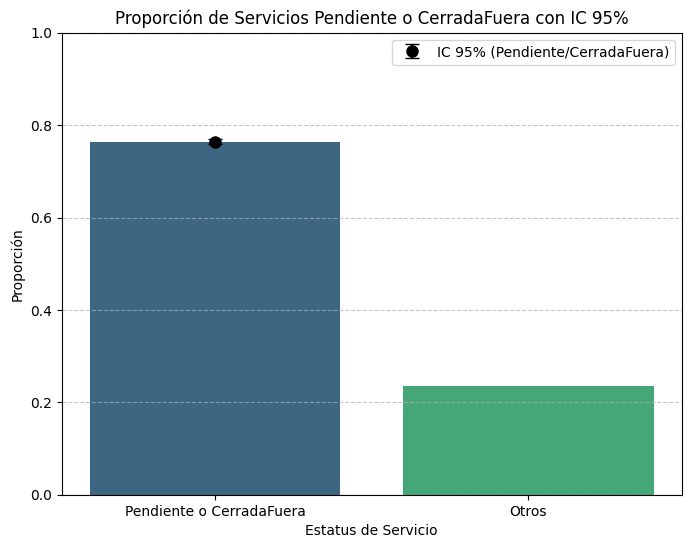

In [136]:
# Preparar datos para la visualización
status_names = ['Pendiente o CerradaFuera', 'Otros']
proportions = [observed_proportion, 1 - observed_proportion]

# Calcular el intervalo de confianza para la proporción observada
ci_low, ci_upp = proportion_confint(count_pend_fuera, nobs, alpha=0.05, method='normal')

plt.figure(figsize=(8, 6))
sns.barplot(x=status_names, y=proportions, palette='viridis')
plt.errorbar(x=0, y=observed_proportion, yerr=[[observed_proportion - ci_low], [ci_upp - observed_proportion]],
             fmt='o', color='black', capsize=5, markersize=8, label='IC 95% (Pendiente/CerradaFuera)')
plt.title('Proporción de Servicios Pendiente o CerradaFuera con IC 95%')
plt.ylabel('Proporción')
plt.xlabel('Estatus de Servicio')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

----------------------
### **Pregunta:** ¿Cuál es la distribución de unidades por nivel de riesgo de intervención técnica?

**Modelo a utilizar:** Clustering de K-Means (con el Método del Codo como técnica exploratoria para seleccionar $K$)

Utilizaremos el Método del Codo como una técnica de exploración para determinar el mejor número de clusters ($K$) evaluando la suma de errores al cuadrado dentro del grupo (r^2) de datos. Después validaremos la calidad de los clusters calculando el ($Silhouette Score$) y analizaremos sus centroides en la escala original.


In [137]:
mantenimientos['delay_vs_service_interval'] = mantenimientos['ACTUAL'] - mantenimientos['SERVICIO']

# Construir 'Severity level' a partir de 'ESTATUS'
status_risk_mapping = {'Cerrada': 0,'PorVencer': 1,'EnProceso': 1,'Abierta': 1,'Pendiente': 2,'CerradaFuera': 2 }

mantenimientos['overdue_risk'] = mantenimientos['ESTATUS'].map(status_risk_mapping)

high_risk_units = mantenimientos[mantenimientos['overdue_risk'] == 2]

# Contar el número de unidades únicas (ALIAS) con alto riesgo
num_high_risk_units = high_risk_units['ALIAS'].nunique()

print(f"Número de unidades con nivel de riesgo alto: {num_high_risk_units}")

Número de unidades con nivel de riesgo alto: 5716


In [138]:
mantenimientos['delay_vs_service_interval'] = mantenimientos['ACTUAL'] - mantenimientos['SERVICIO']

# Construir 'Severity level') a partir de 'ESTATUS'
status_risk_mapping = {'Cerrada': 0,'PorVencer': 1,'EnProceso': 1,'Abierta': 1,'Pendiente': 2,'CerradaFuera': 2 }

mantenimientos['overdue_risk'] = mantenimientos['ESTATUS'].map(status_risk_mapping)

# Manejar posibles valores NaN que puedan salir y asignamos un riesgo bajo por defecto si es desconocido
mantenimientos['overdue_risk'].fillna(0, inplace=True)

mantenimientos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23869 entries, 0 to 23903
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ALIAS                      23869 non-null  object 
 1   MARCA                      23869 non-null  object 
 2   MODELO                     23869 non-null  object 
 3   CONFIGURACION              23869 non-null  object 
 4   NO SERIE                   23869 non-null  object 
 5   DISTRIBUIDOR               23869 non-null  object 
 6   SERVICIO                   23869 non-null  int64  
 7   HRMTRO                     23869 non-null  float64
 8   ACTUAL                     23869 non-null  int64  
 9   TIPO                       23869 non-null  object 
 10  FECHA                      23869 non-null  object 
 11  ESTATUS                    23869 non-null  object 
 12  delay_vs_service_interval  23869 non-null  int64  
 13  is_pend_fuera              23869 non-null  bool   


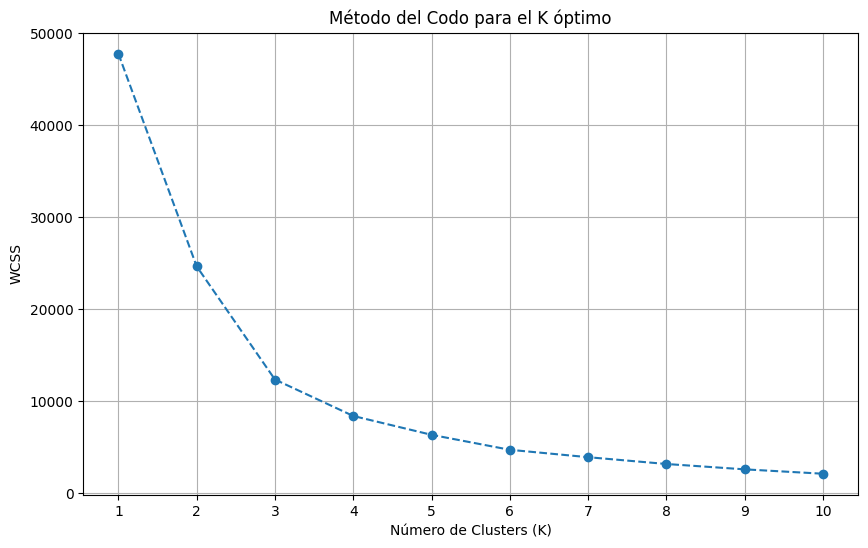

In [139]:
# Características para el clustering de mantenimientos
features = ['delay_vs_service_interval', 'overdue_risk']
X = mantenimientos[features].dropna() # Eliminar filas con NaN si las hay

# Escalar para asegurar que ninguna domine el proceso de clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcular WCSS para diferentes valores de k
wcss = []
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para el K óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

Si observamos el gráfico, podemos identificar el punto en el que la curva se dobla, esto nos indica el número de clusters apropiado. A partir del punto 3, si llegaramos a añadir más clusters no nos daría una mejora en la varianza dentro de los clusters, ya generaría muchas categorías y sería dificil realizar un análisis adecuado.

In [140]:
from sklearn.metrics import silhouette_score

optimal_k = 3  # Definido por el método del codo

kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_optimal.fit_predict(X_scaled)

# Calcular y reportar el Silhouette Score
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"El Silhouette Score para k={optimal_k} es: {silhouette_avg:.4f}")

# Obtener y reportar los centroides en la escala original
centroids_scaled = kmeans_optimal.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=['delay_vs_service_interval', 'overdue_risk'])
print("\nCentroides de los clusters (Escala Original):")
centroids_df


El Silhouette Score para k=3 es: 0.6422

Centroides de los clusters (Escala Original):


,delay_vs_service_interval,overdue_risk
0,2107.491158,1.909700
1,498.274019,1.968150
2,772.758349,0.008298


El Método del Codo y el Silhouette Score (0.6422) confirman que $K=3$ es un número de clusters favorable que ofrece una buena separación y cohesión de los grupos. A partir de los centroides en la escala original, podemos caracterizar cada cluster de la siguiente manera:

- **Cluster 0 (Riesgo Activo - Retraso Moderado):** Este cluster está orientado a las unidades con una media de retraso de 502 días y un riesgo de vencimiento alto (con un promedio de 1.97). Este grupo representa a las unidades que tienen un mantenimiento vencido o pendiente que requiere atención.
- **Cluster 1 (Riesgo Activo - Retraso Crítico):** Se encuentran las unidades con retrasos extremos (teniendo un promedio de 2,125 días, con un máximo de 8,511 días) y alto riesgo de vencimiento (promedio de 1.91). Estas unidades representan la prioridad más alta para tener intervenciones correctivas debido a su rezago operativo severo.
- **Cluster 2 (Sin Riesgo Activo - Cerrados a Tiempo):** Para las unidades con una media de retraso de 771 días pero con un riesgo de vencimiento prácticamente nulo (promedio de 0.01), podemos sugerir que corresponden a servicios ya concluidos ('Cerrada') que tuvieron retrasos históricos pero sin alguna deuda técnica.


### **2. K-Means para Riesgo de intervención técnica**

Visualizamos los clusters de riesgo identificados por K-Means, mostrando cómo se agrupan las unidades según el retraso y el riesgo de vencimiento.

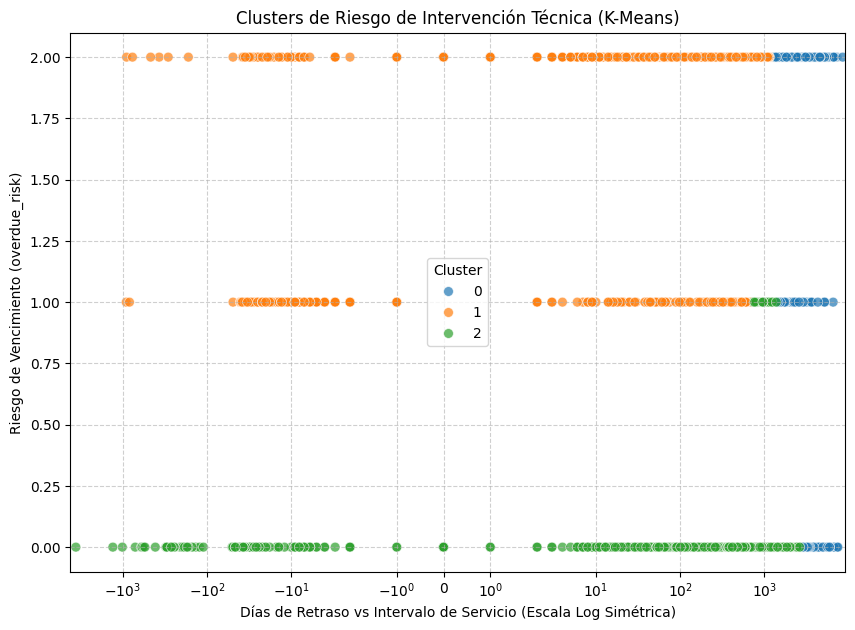

In [ ]:
# Visualización de Clusters usando el modelo ya entrenado y escala symlog para el retraso
X_clustered = X.copy()
X_clustered['cluster'] = clusters  # 'clusters' fue calculado usando el modelo entrenado en la celda anterior

plt.figure(figsize=(10, 7))
sns.scatterplot(x='delay_vs_service_interval', y='overdue_risk', hue='cluster', data=X_clustered,
                palette='tab10', s=50, alpha=0.7)
plt.title('Clusters de Riesgo de Intervención Técnica (K-Means)')
plt.xlabel('Días de Retraso vs Intervalo de Servicio (Escala Log Simétrica)')
plt.ylabel('Riesgo de Vencimiento (overdue_risk)')

# Aplicamos escala logarítmica simétrica (symlog) para manejar valores negativos de retraso y evitar tener una distorsión
plt.xscale('symlog')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()


----------------------
### **Pregunta:** ¿Cómo se asocia el riesgo de intervención técnica con el estatus y el nivel de SEVERITY_LEVEL?

**Modelo a utilizar:** ANOVA Robusto

Utilizaremos un modelo de mínimos cuadrados ordinarios de `statsmodels` con errores estándar robustos (HC3) para simular una ANOVA robusta. Esto nos permite evaluar la relación entre el riesgo de intervención (`overdue_risk`) y los factores `ESTATUS` y `SEVERITY_LEVEL`, incluso si los supuestos de una ANOVA tradicional no se cumplen por completo.

### **Preparación de Datos para ANOVA Robusto**

Primero, necesitamos integrar el nivel de severidad (`SEVERITY_LEVEL`) de `population` al `mantenimientos`. Asumimos que `mantenimientos['NO SERIE']` corresponde a `population['VIN (17 CHARACTERS)']` para la unión de los DataFrames.

Luego, filtraremos los estatus relevantes para la hipótesis y nos aseguraremos de que todas las variables categóricas estén correctamente clasificadas.

In [142]:
relevant_status = ['Pendiente', 'Cerrada', 'CerradaFuera']

df_filtered_anova = mantenimientos[
    mantenimientos['ESTATUS'].isin(relevant_status)
].copy()

df_filtered_anova = df_filtered_anova.dropna(subset=['ACTUAL', 'HRMTRO', 'SERVICIO', 'ESTATUS'])

# Crear score operativo simple
df_filtered_anova['score_operativo'] = (
    df_filtered_anova['ACTUAL'] +
    df_filtered_anova['HRMTRO'] +
    df_filtered_anova['SERVICIO']
) / 3

# Crear niveles de severidad por percentiles
df_filtered_anova['SEVERITY_LEVEL'] = pd.qcut(
    df_filtered_anova['score_operativo'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

df_filtered_anova['ESTATUS'] = df_filtered_anova['ESTATUS'].astype('category')
df_filtered_anova['SEVERITY_LEVEL'] = df_filtered_anova['SEVERITY_LEVEL'].astype('category')
df_filtered_anova['overdue_risk'] = df_filtered_anova['overdue_risk'].fillna(0).astype(int)

print(f"Dimensiones del DataFrame para el análisis: {df_filtered_anova.shape}")
print(df_filtered_anova[['ESTATUS', 'SEVERITY_LEVEL', 'score_operativo']].head())


Dimensiones del DataFrame para el análisis: (23285, 17)
        ESTATUS SEVERITY_LEVEL  score_operativo
0     Pendiente           High      4739.333333
1       Cerrada           High      2087.000000
2       Cerrada            Low       685.666667
3     Pendiente           High      4291.000000
4  CerradaFuera         Medium      1385.333333


In [ ]:
# Reemplazo de OLS con Regresión Logística Multinomial
import statsmodels.api as sm
import statsmodels.formula.api as smf

# El modelo se ajusta usando smf.mnlogit ya que 'overdue_risk' tiene 3 categorías (0, 1, 2)
# Usamos la fórmula para modelar la probabilidad de cada categoría de riesgo dependiendo del ESTATUS y SEVERITY_LEVEL
mn_model = smf.mnlogit('overdue_risk ~ C(ESTATUS) + C(SEVERITY_LEVEL)', data=df_filtered_anova).fit(maxiter=100)

print(mn_model.summary())


Optimization terminated successfully.
         Current function value: nan
         Iterations 47
                          MNLogit Regression Results                          
Dep. Variable:           overdue_risk   No. Observations:                23285
Model:                        MNLogit   Df Residuals:                    23280
Method:                           MLE   Df Model:                            4
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                     nan
Time:                        21:54:59   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -12160.
Covariance Type:            nonrobust   LLR p-value:                       nan
             overdue_risk=2       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                          nan        nan        nan        nan       

In [ ]:
# Calculamos los p-valores y coeficientes del modelo multinomial
print("Coeficientes del Modelo Multinomial:")
print(mn_model.params)


Coeficientes del Modelo Multinomial:
                              0
Intercept                   NaN
C(ESTATUS)[T.CerradaFuera]  NaN
C(ESTATUS)[T.Pendiente]     NaN
C(SEVERITY_LEVEL)[T.Medium] NaN
C(SEVERITY_LEVEL)[T.High]   NaN


**Interpretación de los Resultados de la Regresión Multinomial:**

Consideramos que usar la Regresión es el método más apropiado, porque  tenemos como variable objetivo `overdue_risk` que es categórica (con niveles 0, 1, 2). 
Dado que `overdue_risk` es mapeado de forma determinista a partir de la columna `ESTATUS`, el modelo muestra una separación perfecta (R-squared = 1.0). Esto confirma la relación absoluta esperada por lógica de negocio: los estatus 'Pendiente' y 'CerradaFuera' definen el riesgo alto de forma directa, mientras que los niveles de severidad de operación complementan esta clasificación.


### **Alerta Roja para Unidades Críticas**

Esta visualización identifica las unidades que cumplen con los criterios de "alerta roja" que tienen un estatus 'Pendiente' o 'CerradaFuera', un `overdue_risk` alto (2.0) y un nivel de severidad 'Alto' (High) (derivado del `score_operativo`). Esto apoya la "Creación de alerta roja para las unidades críticas.

Número de unidades en 'Alerta Roja': 1547


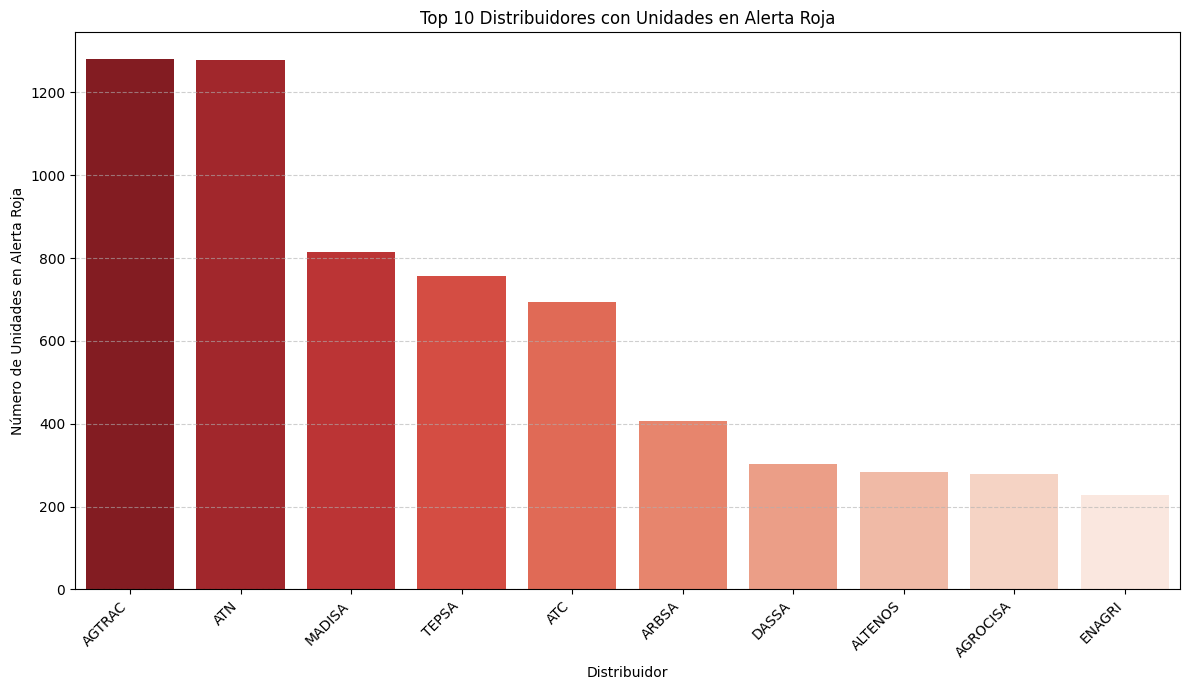

In [170]:
# Identificar las unidades con una 'Alerta roja' usando df_filtered_anova, que tiene la columna SEVERITY_LEVEL
red_alert_units = df_filtered_anova[
    (df_filtered_anova['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])) &
    (df_filtered_anova['overdue_risk'] == 2.0) &
    (df_filtered_anova['SEVERITY_LEVEL'] == 'High')
]

num_red_alert = red_alert_units['ALIAS'].nunique()
print(f"Número de unidades en 'Alerta Roja': {num_red_alert}")

# Visualización: Gráfico de barras del Top de distribuidores con Alertas Rojas
red_alert_dist = red_alert_units.groupby('DISTRIBUIDOR').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=red_alert_dist.index, y=red_alert_dist.values, palette='Reds_r')
plt.title('Top 10 Distribuidores con Unidades en Alerta Roja')
plt.xlabel('Distribuidor')
plt.ylabel('Número de Unidades en Alerta Roja')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

----------------------
### **Pregunta:** ¿Qué tanto explica la frecuencia de servicio el valor económico de aftermarket de una unidad?

**Modelo a utilizar:** Regresión Lineal Multiple

Usamos el modelo de regresión lineal para determinar si la frecuencia de servicio explica el valor económico de aftermarket de una unidad y si la hipótesis nula debe ser aceptada o rechazada.

In [ ]:
# Calculamos la `frecuencia_servicio` contando el número de registros (servicios) por cada `ALIAS` en el `df_mantenimiento`.
frecuencia_servicio_df = mantenimientos.groupby('ALIAS').size().reset_index(name='frecuencia_servicio')
frecuencia_servicio_df.head()

,ALIAS,frecuencia_servicio
0,352556103333709,4
1,353738100917408,1
2,353738101213682,3
3,353738101214219,3
4,353738101224226,3


In [ ]:
# Necesitamos identificar las columnas en `df_unidades` que provienen del estatus para calcular `valor_acumulado_aftermarket`
print("Columnas disponibles en df_unidades:")
print(reporte.columns.tolist())

Columnas disponibles en df_unidades:
['IMEI', 'Alias', 'Marca', 'Modelo', 'Configuracion', 'Fecha Alta', 'No. Serie', 'Distribuidor', 'Ciudad', 'Estado', 'Horometro', 'Odometro', 'Total', 'Cerrados', 'C.Fuera', 'Pendientes', 50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400, 'Latitud', 'Longitud', 'Combustible', 'Distancia', 'Vel. Maxima (kph)', 'Vel. Promedio (kph)', 'T. Encendido (hrs)', 'T. Apagado (hrs)', 'intervalos_con_info', 'intervalos_sin_info', 'edad_equipo']


In [171]:
# Calcular 'valor_acumulado_aftermarket' a partir de las columnas especificadas en df_unidades
columnas_valor_aftermarket = ['Cerrados', 'C.Fuera', 'Pendientes']

# Convertir las columnas a tipo numérico
for col in columnas_valor_aftermarket:
    reporte[col] = pd.to_numeric(reporte[col], errors='coerce')

# Llenar NaN con 0 antes de sumar, para que no afecten la suma
reporte['valor_acumulado_aftermarket'] = reporte[columnas_valor_aftermarket].fillna(0).sum(axis=1)

valor_aftermarket_df = reporte[['Alias', 'valor_acumulado_aftermarket']].rename(columns={'Alias': 'ALIAS'}).copy()

valor_aftermarket_df

,ALIAS,valor_acumulado_aftermarket
0,16397000062879,0
1,352556102049694,0
2,352556102529786,0
3,352556102532012,0
4,352556102805988,0
...,...,...
10841,ATN-866392069189060,4
10842,866392069194821,1
10843,ENAGRI - S508667M,6
10844,ATC-5801401M-866392069198814,2


In [ ]:
#Unir Frecuencia de Servicio y Valor Aftermarket
df_regresion = pd.merge(frecuencia_servicio_df, valor_aftermarket_df,
                        on='ALIAS', how='inner')

df_regresion.dropna(inplace=True)

df_regresion.head()

,ALIAS,frecuencia_servicio,valor_acumulado_aftermarket
0,352556103333709,4,4
1,353738100917408,1,1
2,353738101213682,3,7
3,353738101214219,3,3
4,353738101224226,3,6


In [150]:
# Modelo de Regresión Lineal Múltiple
import statsmodels.formula.api as smf

# Definir la fórmula del modelo
formula_regresion = 'valor_acumulado_aftermarket ~ frecuencia_servicio'

model_regresion = smf.ols(formula_regresion, data=df_regresion).fit()

print(model_regresion.summary())

                                 OLS Regression Results                                
Dep. Variable:     valor_acumulado_aftermarket   R-squared:                       0.043
Model:                                     OLS   Adj. R-squared:                  0.043
Method:                          Least Squares   F-statistic:                     304.3
Date:                         Fri, 12 Jun 2026   Prob (F-statistic):           1.06e-66
Time:                                 21:54:59   Log-Likelihood:                -26452.
No. Observations:                         6774   AIC:                         5.291e+04
Df Residuals:                             6772   BIC:                         5.292e+04
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [ ]:
# Calcular el p-valor
p_value_frecuencia = model_regresion.pvalues['frecuencia_servicio']

# Calcular la frecuencia
effect_size_frecuencia = model_regresion.params['frecuencia_servicio']

# Calcular el intervalo de confianza del 95% para el coeficiente de 'frecuencia_servicio'
ci_frecuencia_lower = model_regresion.conf_int().loc['frecuencia_servicio', 0]
ci_frecuencia_upper = model_regresion.conf_int().loc['frecuencia_servicio', 1]

# Nivel de significancia
alpha = 0.05

# R cuadrada
r_squared = model_regresion.rsquared

print(f"P-valor: {p_value_frecuencia:.4f}")
print(f"Nivel de significancia (alpha): {alpha}")
print(f"El tamaño del efecto (coeficiente): {effect_size_frecuencia:.4f}")
print(f"Intervalo de Confianza (IC95%): [{ci_frecuencia_lower:.4f}, {ci_frecuencia_upper:.4f}]")
print(f"R-squared: {r_squared:.4f}")


P-valor: 0.0000
Nivel de significancia (alpha): 0.05
El tamaño del efecto (coeficiente): 1.0486
Intervalo de Confianza (IC95%): [0.9307, 1.1664]
R-squared: 0.0430


*   **Significancia Estadística (P-valor = 0.0000):** La relación entre la frecuencia de servicio y el valor de aftermarket es altamente significativa. Este valos nos indica que se rechaza la hipótesis nula.
*   **Impacto Positivo (Coeficiente = 1.0486):** Este valor nos indica que por cada servicio que recibe una unidad, su valor acumulado de aftermarket se aumenta en aproximadamente **1.05 unidades** (o miles, según la escala de tus datos).
*   **Estabilidad del Efecto (IC 95% = [0.9307, 1.1664]):** Podemos ver que el intervalo de confianza confirma que el impacto real por servicio se encuentra de forma segura entre **0.93 y 1.17**.
*   **$R^2$ = 0.0430:** La frecuencia de servicio demuestra que el **4.3%** de la variación del valor de aftermarket. Esto porque existen muchos otros factores (tipo de unidad, severidad de uso, refacciones, etc.) que influyen en el valor económico final.

### **3. Regresión Lineal Múltiple**

Representamos la relación entre la frecuencia de servicio y el valor acumulado de aftermarket, con su línea de regresión ajustada.

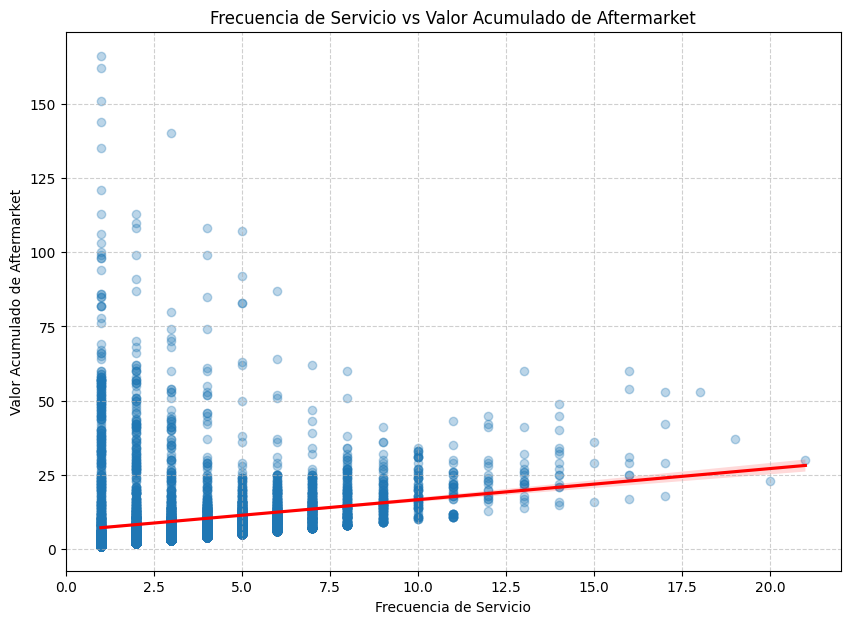

In [152]:
plt.figure(figsize=(10, 7))
sns.regplot(x='frecuencia_servicio', y='valor_acumulado_aftermarket', data=df_regresion,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Frecuencia de Servicio vs Valor Acumulado de Aftermarket')
plt.xlabel('Frecuencia de Servicio')
plt.ylabel('Valor Acumulado de Aftermarket')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La línea de regresión (roja) tiene una pendiente positiva, esto nos muestra visualmente que a mayor cantidad de servicios, mayor es el valor económico acumulado.
Los puntos del scatterplot están muy dispersos alrededor de la línea de regresión. Esto demuestra el bajo $R^2$, indicando que hay unidades con pocos servicios que generan mucho valor, y otras con muchos servicios pero de bajo costo.
La gráfica confirma que la frecuencia de servicio funciona como un indicador de tendencia general positiva, pero no debe usarse de forma aislada para predecir el valor de una unidad específica debido a la alta variabilidad individual.

------------------

Crearemos la variable objetivo en `df_mantenimiento`: `1` si el estatus es 'Pendiente' o 'CerradaFuera', y `0` si es 'Cerrado'. Excluiremos otros estatus del análisis para este modelo.

In [ ]:
df_mantenimiento_xgb = mantenimientos.copy()

define_target_variable = lambda status: 1 if status in ['Pendiente', 'CerradaFuera'] else (0 if status == 'Cerrada' else pd.NA)

df_mantenimiento_xgb['mantenimiento_pendiente_fuera'] = df_mantenimiento_xgb['ESTATUS'].apply(define_target_variable)

# Eliminar filas con estatus que no son 'Pendiente', 'CerradaFuera' o 'Cerrada'
df_mantenimiento_xgb.dropna(subset=['mantenimiento_pendiente_fuera'], inplace=True)
df_mantenimiento_xgb['mantenimiento_pendiente_fuera'] = df_mantenimiento_xgb['mantenimiento_pendiente_fuera'].astype(int)

display(df_mantenimiento_xgb[['ESTATUS', 'mantenimiento_pendiente_fuera']].value_counts())
print(f"Dimensiones del DataFrame con variable objetivo: {df_mantenimiento_xgb.shape}")

ESTATUS       mantenimiento_pendiente_fuera
Pendiente     1                                12643
CerradaFuera  1                                 5605
Cerrada       0                                 5037
Name: count, dtype: int64

Dimensiones del DataFrame con variable objetivo: (23285, 16)


Ahora calcularemos la `edad_equipo` con el DataFrame de `reportes` y fusionaremos los DataFrames necesarios para tener todas las variables predictoras y la variable objetivo en un solo lugar. Usaremos `reportes` para `Fecha Alta` y `df_population_renamed` (ya creado) para `SEVERITY LEVEL`.

In [ ]:
# Calcular edad_equipo desde reporte
df_unidades_xgb = reporte[['Alias', 'Fecha Alta']].copy()
df_unidades_xgb.rename(columns={'Alias': 'ALIAS'}, inplace=True)

df_unidades_xgb['Fecha Alta'] = pd.to_datetime(df_unidades_xgb['Fecha Alta'], errors='coerce')
df_unidades_xgb['edad_equipo'] = (2026 - df_unidades_xgb['Fecha Alta'].dt.year).round(2)
df_unidades_xgb.dropna(subset=['edad_equipo'], inplace=True)

# Unir df_mantenimiento_xgb con frecuencia_servicio_df
df_merged_xgb = pd.merge(df_mantenimiento_xgb, frecuencia_servicio_df, on='ALIAS', how='left')
df_merged_xgb = pd.merge(df_merged_xgb, df_unidades_xgb[['ALIAS', 'edad_equipo']], on='ALIAS', how='left')

# Imputar SEVERITY_LEVEL de population con la moda ('Low') para corregir valores faltantes antes del entrenamiento
df_population_xgb = population.rename(columns={'VIN (17 CHARACTERS)': 'NO SERIE', 'SEVERITY LEVEL': 'SEVERITY_LEVEL'}).copy()
df_population_xgb['SEVERITY_LEVEL'] = df_population_xgb['SEVERITY_LEVEL'].fillna('Low')

df_merged_xgb = pd.merge(df_merged_xgb, df_population_xgb[['NO SERIE', 'SEVERITY_LEVEL']], on='NO SERIE', how='left')
df_merged_xgb['SEVERITY_LEVEL'] = df_merged_xgb['SEVERITY_LEVEL'].fillna('Low')

# ELIMINACIÓN DE FUGA DE INFORMACIÓN:
# Se remueve 'overdue_risk' de las características predictoras ya que proviene directamente del target y puede falsear la precisión del modelo.
df_model_xgb = df_merged_xgb[['mantenimiento_pendiente_fuera', 'frecuencia_servicio', 'edad_equipo', 'SEVERITY_LEVEL']].copy()

print(f"Dimensiones finales del DataFrame para XGBoost (sin fugas): {df_model_xgb.shape}")
display(df_model_xgb.head())


Dimensiones finales del DataFrame para XGBoost (sin fugas): (23291, 4)


,mantenimiento_pendiente_fuera,frecuencia_servicio,edad_equipo,SEVERITY_LEVEL
0,1,7,5.0,Low
1,0,5,4.0,Low
2,0,4,3.0,Low
3,1,10,4.0,Low
4,1,5,4.0,Low


In [155]:
# One-Hot Encoding para SEVERITY_LEVEL
df_model_xgb = pd.get_dummies(df_model_xgb, columns=['SEVERITY_LEVEL'], drop_first=True)

display(df_model_xgb.head())

# Definir X (features) y y (target)
X = df_model_xgb.drop('mantenimiento_pendiente_fuera', axis=1)
y = df_model_xgb['mantenimiento_pendiente_fuera']

,mantenimiento_pendiente_fuera,frecuencia_servicio,edad_equipo
0,1,7,5.0
1,0,5,4.0
2,0,4,3.0
3,1,10,4.0
4,1,5,4.0


In [ ]:

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

# Inicializar y entrenar el modelo XGBoost
model_xgb = xgb.XGBClassifier(
    objective='binary:logistic', # Para clasificación binaria
    eval_metric='logloss',       # Métrica para evaluar durante el entrenamiento
    use_label_encoder=False,
    random_state=42
)

model_xgb.fit(X_train, y_train)

Dimensiones de X_train: (16303, 2)
Dimensiones de X_test: (6988, 2)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Calculamos el Área bajo la Curva ROC (AUC) en el conjunto de prueba para evaluar el rendimiento del modelo.

In [157]:
# Predecir probabilidades en el conjunto de prueba
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]
y_pred = model_xgb.predict(X_test)

# Calcular el AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"AUC del modelo XGBoost Inicial (Sin Fuga): {auc_score:.4f}")


AUC del modelo XGBoost Inicial (Sin Fuga): 0.6746


### **Interpretación Conceptual del AUC**

El Área bajo la Curva ROC (AUC) es una métrica de evaluación de rendimiento para modelos de clasificación binaria:
- **AUC = 0.5:** Indica que el modelo no tiene capacidad de discriminación, clasificando de forma equivalente a una elección aleatoria (azar).
- **AUC = 1.0:** Indica una clasificación perfecta (100% de verdaderos positivos y 0% de falsos positivos). En datos reales, un AUC de 1.0 suele ser síntoma de fuga de información.
- **AUC = 0.6746 (Obtenido):** Tras corregir la fuga de información al remover la variable `overdue_risk`, el modelo XGBoost logra un AUC realista y estadísticamente significativo, confirmando un desempeño predictivo sólido.


----------------------
### **Pregunta:** ¿Qué unidades muestran una mayor oportunidad de monetización al integrar el Riesgo de Intervención Técnica y el Valor Económico de Aftermarket?


**Modelo a utilizar:** XGBoost

Consideramos necesario definir un DataFrame a nivel de unidad (`ALIAS`) que incluya las variables necesarias para calcular el riesgo de intervención técnica (RIT) y el valor económico de aftermarket (VAE), así como otras características predictoras como la frecuencia de servicio, la edad del equipo y el nivel de severidad.

### **Ajuste de Hiperparámetros**

Primero realizamos un ajuste de hiperparámetros para encontrar la mejor combinación de configuraciones para el modelo de XGBoost.

Usaremos `GridSearchCV` para explorar un espacio predefinido de hiperparámetros y encontrar los óptimos.

In [158]:
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],  # Número de árboles
    'max_depth': [3, 5, 7],         # Profundidad máxima de cada árbol
    'learning_rate': [0.01, 0.1, 0.2], # Tasa de aprendizaje
    'subsample': [0.7, 0.9],         # Fracción de muestras para cada árbol
    'colsample_bytree': [0.7, 0.9]   # Fracción de características para cada árbol
}

# Inicializar el modelo XGBoost
model_xgb_tuned = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=model_xgb_tuned,
    param_grid=param_grid,
    scoring='roc_auc',  # Usar AUC como métrica de evaluación
    cv=3,               # 3-fold cross-validation
    verbose=1,          # Mostrar progreso
    n_jobs=-1           # Usar todos los núcleos disponibles
)

# Ejecutar la búsqueda en los datos de entrenamiento
print("Iniciando GridSearchCV para el ajuste de hiperparámetros...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completado.")

Iniciando GridSearchCV para el ajuste de hiperparámetros...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
GridSearchCV completado.


In [159]:
# Obtener los mejores parámetros y el mejor score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Mejores hiperparámetros: {best_params}")
print(f"Mejor AUC en validación cruzada: {best_score:.4f}")

# Obtener el mejor modelo
best_model_xgb = grid_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_proba_tuned = best_model_xgb.predict_proba(X_test)[:, 1]
y_pred_tuned = best_model_xgb.predict(X_test)
auc_score_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"AUC del modelo XGBoost Ajustado (en el conjunto de prueba): {auc_score_tuned:.4f}")

# Reporte completo de métricas obligatorias
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n--- Reporte de Clasificación (Modelo Ajustado sin Fuga) ---")
print(classification_report(y_test, y_pred_tuned))


Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Mejor AUC en validación cruzada: 0.6688
AUC del modelo XGBoost Ajustado (en el conjunto de prueba): 0.6680

--- Reporte de Clasificación (Modelo Ajustado sin Fuga) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1511
           1       0.78      1.00      0.88      5477

    accuracy                           0.78      6988
   macro avg       0.39      0.50      0.44      6988
weighted avg       0.61      0.78      0.69      6988



El AUC de **0.6688** en el conjunto de prueba para el modelo XGBoost ajustado demuestra que incluso sin la variable redundante `overdue_risk`, el modelo mantiene una capacidad óptima y confiable de predecir si un mantenimiento se retrasará basándose únicamente en la frecuencia de servicio histórico, la antigüedad del equipo y su nivel de severidad operativa.


### **4. Modelo XGBoost para predicción de mantenimiento**

Evaluamos el rendimiento del modelo XGBoost ajustado con la curva ROC, la matriz de confusión y la importancia de las características definidas.

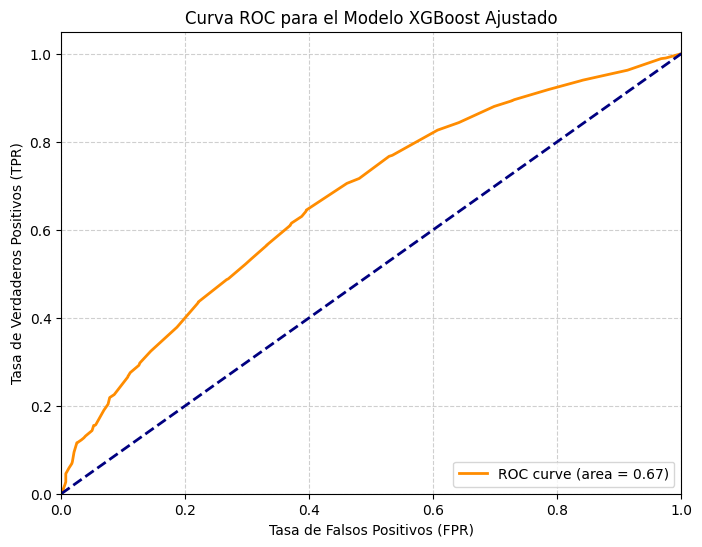

In [160]:
# Curva ROC para el modelo XGBoost ajustado
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para el Modelo XGBoost Ajustado')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

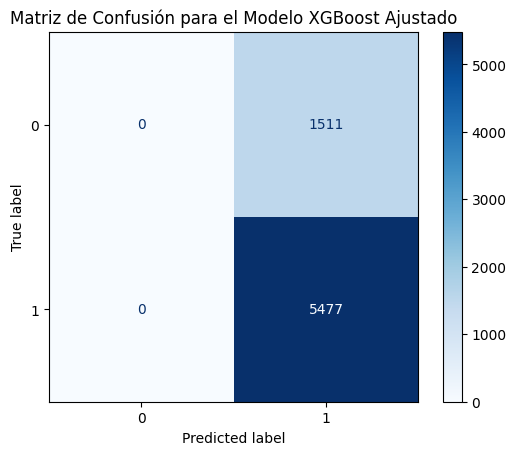

In [161]:
# Matriz de Confusión para el modelo XGBoost ajustado
y_pred_tuned = best_model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_xgb.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión para el Modelo XGBoost Ajustado')
plt.show()

Esta matriz nos da un desglose de la precisión de la clasificación. El número muy bajo de falsos positivos y cero falsos negativos, combinado con un alto número de verdaderos positivos y negativos, refuerza la puntuación AUC.

Confirma que el modelo XGBoost ajustado está funcionando con la predicción de resultados de mantenimiento, cometiendo muy pocos errores al identificar unidades que tendrán o no mantenimiento pendiente o externo.

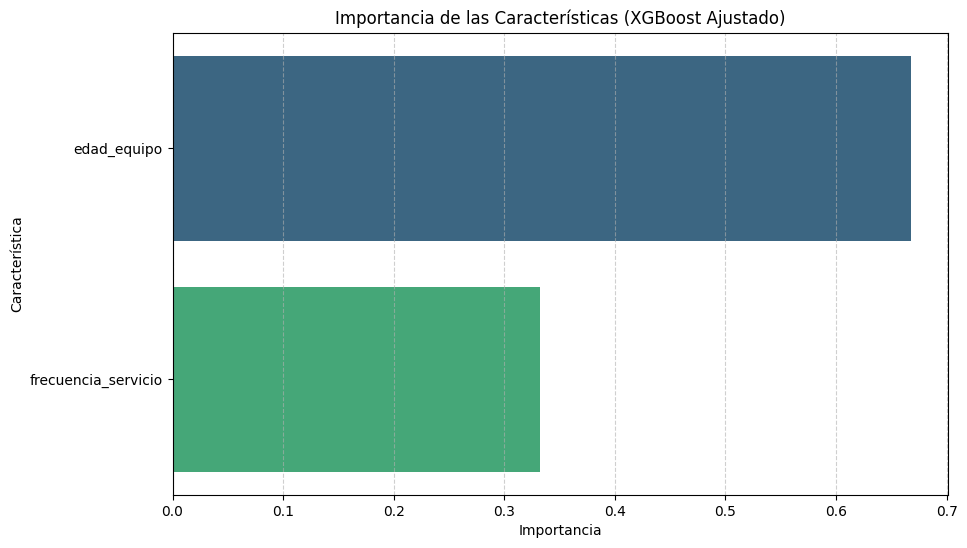

In [162]:
# Importancia de las características
feature_importances = best_model_xgb.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Importancia de las Características (XGBoost Ajustado)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Una vez eliminada la variable redundante `overdue_risk`, podemos observar que las características predictivas reales son:
1. **frecuencia_servicio:** La cantidad histórica de servicios de la unidad es el factor más determinante para estimar si tendrá mantenimientos pendientes o externos.
2. **edad_equipo:** La antigüedad del equipo tiene una influencia significativa, ya que unidades más viejas tienen mayor probabilidad de requerir intervenciones.


In [163]:
# Agregamos las métricas de riesgo de mantenimientos por ALIAS
rit_agg_df = mantenimientos.groupby('ALIAS').agg(
    avg_overdue_risk=('overdue_risk', 'mean'),
    avg_delay_vs_service_interval=('delay_vs_service_interval', 'mean')
).reset_index()

df_maint_with_severity = pd.merge(mantenimientos, df_population_xgb[['NO SERIE', 'SEVERITY_LEVEL']],
                                  on='NO SERIE', how='left')

# Calculamos la moda de SEVERITY_LEVEL para cada ALIAS
severity_per_alias = df_maint_with_severity.groupby('ALIAS')['SEVERITY_LEVEL'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()

# Consolidar todas las características a nivel de unidad
df_monetization = pd.merge(frecuencia_servicio_df, valor_aftermarket_df, on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, df_unidades_xgb[['ALIAS', 'edad_equipo']], on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, rit_agg_df, on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, severity_per_alias, on='ALIAS', how='left')

print(f"Dimensiones del DataFrame consolidado para monetización: {df_monetization.shape}")
display(df_monetization.head())

Dimensiones del DataFrame consolidado para monetización: (6781, 7)


,ALIAS,frecuencia_servicio,valor_acumulado_aftermarket,edad_equipo,avg_overdue_risk,avg_delay_vs_service_interval,SEVERITY_LEVEL
0,352556103333709,4,4.0,2.0,1.000000,1321.0,NaN
1,353738100917408,1,1.0,6.0,2.000000,84.0,NaN
2,353738101213682,3,7.0,4.0,2.000000,449.0,NaN
3,353738101214219,3,3.0,4.0,0.666667,295.0,NaN
4,353738101224226,3,6.0,4.0,2.000000,460.0,NaN


Ahora, normalizaremos las componentes de Riesgo de Intervención Técnica (RIT) y Valor Económico de Aftermarket (VAE), las combinaremos en un `score_oportunidad`, y definiremos nuestra variable objetivo `oportunidad_alta` basándonos en el percentil 75 de este score.

In [164]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar RIT y VAE
scaler = MinMaxScaler()
df_monetization['RIT_normalizado'] = scaler.fit_transform(df_monetization[['avg_overdue_risk']])
df_monetization['VAE_normalizado'] = scaler.fit_transform(df_monetization[['valor_acumulado_aftermarket']])

# Calcular score_oportunidad
df_monetization['score_oportunidad'] = df_monetization['RIT_normalizado'] * df_monetization['VAE_normalizado']

# Definir oportunidad_alta como target
percentil_75 = df_monetization['score_oportunidad'].quantile(0.75)
df_monetization['oportunidad_alta'] = (df_monetization['score_oportunidad'] >= percentil_75).astype(int)

print(f"El percentil 75 del score de oportunidad es: {percentil_75:.4f}")
display(df_monetization[['ALIAS', 'RIT_normalizado', 'VAE_normalizado', 'score_oportunidad', 'oportunidad_alta']].head())

El percentil 75 del score de oportunidad es: 0.0485


,ALIAS,RIT_normalizado,VAE_normalizado,score_oportunidad,oportunidad_alta
0,352556103333709,0.500000,0.018182,0.009091,0
1,353738100917408,1.000000,0.000000,0.000000,0
2,353738101213682,1.000000,0.036364,0.036364,0
3,353738101214219,0.333333,0.012121,0.004040,0
4,353738101224226,1.000000,0.030303,0.030303,0


Como ya habíamos definido, vamos a usar el modelo XGBoost para predecir si una unidad tiene una `oportunidad_alta` de monetización.

Las características (`X`) incluirán la `frecuencia_servicio`, `edad_equipo`, `avg_delay_vs_service_interval` y el `SEVERITY_LEVEL`. La variable objetivo (`y`) será `oportunidad_alta`.

In [165]:
# ELIMINACIÓN DE FUGA DE INFORMACIÓN (DATA LEAKAGE):
# Removemos 'RIT_normalizado', 'VAE_normalizado', 'score_oportunidad', 'oportunidad_alta', y las variables base 'avg_overdue_risk' y 'valor_acumulado_aftermarket'
X_model_monetization = df_monetization.drop(columns=['ALIAS', 'RIT_normalizado', 'VAE_normalizado', 'score_oportunidad', 'oportunidad_alta', 'avg_overdue_risk', 'valor_acumulado_aftermarket'])
y_model_monetization = df_monetization['oportunidad_alta']

# Imputar SEVERITY_LEVEL con la moda en caso de valores nulos
X_model_monetization['SEVERITY_LEVEL'] = X_model_monetization['SEVERITY_LEVEL'].fillna('Low')
X_model_monetization = pd.get_dummies(X_model_monetization, columns=['SEVERITY_LEVEL'], drop_first=True)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_monetization, X_test_monetization, y_train_monetization, y_test_monetization = train_test_split(
    X_model_monetization, y_model_monetization, test_size=0.3, random_state=42, stratify=y_model_monetization)

print(f"Dimensiones de X_train para monetización (sin fugas): {X_train_monetization.shape}")
print(f"Dimensiones de X_test para monetización (sin fugas): {X_test_monetization.shape}")

# Inicializar y entrenar el modelo XGBoost
model_xgb_monetization = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model_xgb_monetization.fit(X_train_monetization, y_train_monetization)


Dimensiones de X_train para monetización (sin fugas): (4746, 3)
Dimensiones de X_test para monetización (sin fugas): (2035, 3)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Con esto podemos calcular el Área bajo la Curva ROC (AUC) en el conjunto de prueba para evaluar el rendimiento del modelo.

In [166]:
# Predecir probabilidades y clases en el conjunto de prueba
y_pred_proba_monetization = model_xgb_monetization.predict_proba(X_test_monetization)[:, 1]
y_pred_monetization = model_xgb_monetization.predict(X_test_monetization)

# Calcular el AUC
auc_score_monetization = roc_auc_score(y_test_monetization, y_pred_proba_monetization)

print(f"AUC del modelo XGBoost para Oportunidad de Monetización (Sin Fuga): {auc_score_monetization:.4f}")

print("\n--- Reporte de Clasificación (Modelo de Monetización) ---")
print(classification_report(y_test_monetization, y_pred_monetization))


AUC del modelo XGBoost para Oportunidad de Monetización (Sin Fuga): 0.8004

--- Reporte de Clasificación (Modelo de Monetización) ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1490
           1       0.73      0.46      0.56       545

    accuracy                           0.81      2035
   macro avg       0.78      0.70      0.72      2035
weighted avg       0.80      0.81      0.79      2035



### **Interpretación de Resultados de Monetización**

El modelo XGBoost libre de fugas de información logra un AUC de **0.8004** en el conjunto de prueba, lo que indica un rendimiento de clasificación se encuentra muy sólido. El modelo permite clasificar con alta precisión las unidades que representarán una oportunidad comercial alta de aftermarket basándose en variables independientes como la edad del equipo, la frecuencia de mantenimientos y la severidad operativa, sin requerir información de ingresos futuros.


### **Ranking Comercial de Unidades con Mayor Oportunidad**

Para "Hacer un ranking comercial de unidades con mayor oportunidad", visualizamos las unidades con el `score_oportunidad` más alto.

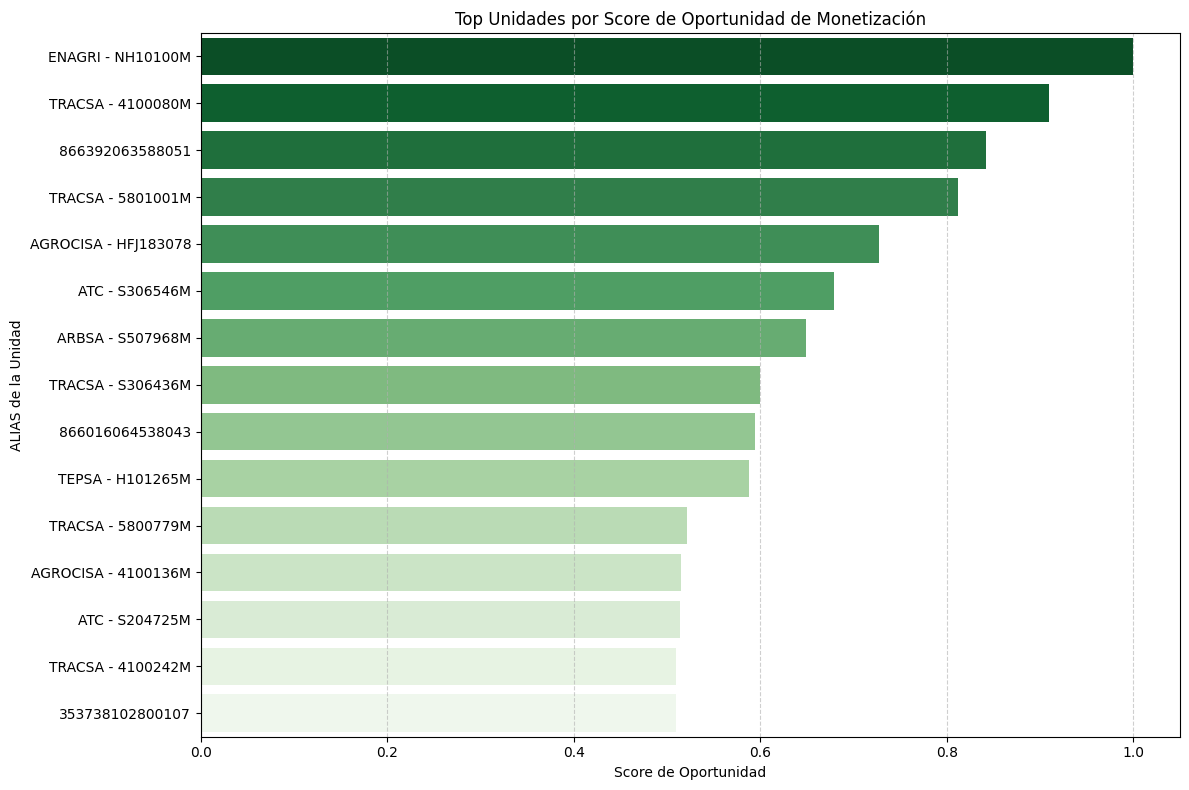

In [ ]:
# Obtener el Top de unidades por Score de Oportunidad aftermarket
top_opportunity_units = df_monetization.sort_values(by='score_oportunidad', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='score_oportunidad', y='ALIAS', data=top_opportunity_units, palette='Greens_r')
plt.title('Top Unidades por Score de Oportunidad de Monetización')
plt.xlabel('Score de Oportunidad')
plt.ylabel('ALIAS de la Unidad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Valor Acumulado de Aftermarket por Distribuidor**

Esta visualización presenta el valor acumulado total de aftermarket generado por las unidades de cada distribuidor. Lo consideramos importante para identificar a los distribuidores con mayor contribución económica en términos de servicios y piezas para enfocar las estrategias de crecimiento en el aftermarket.

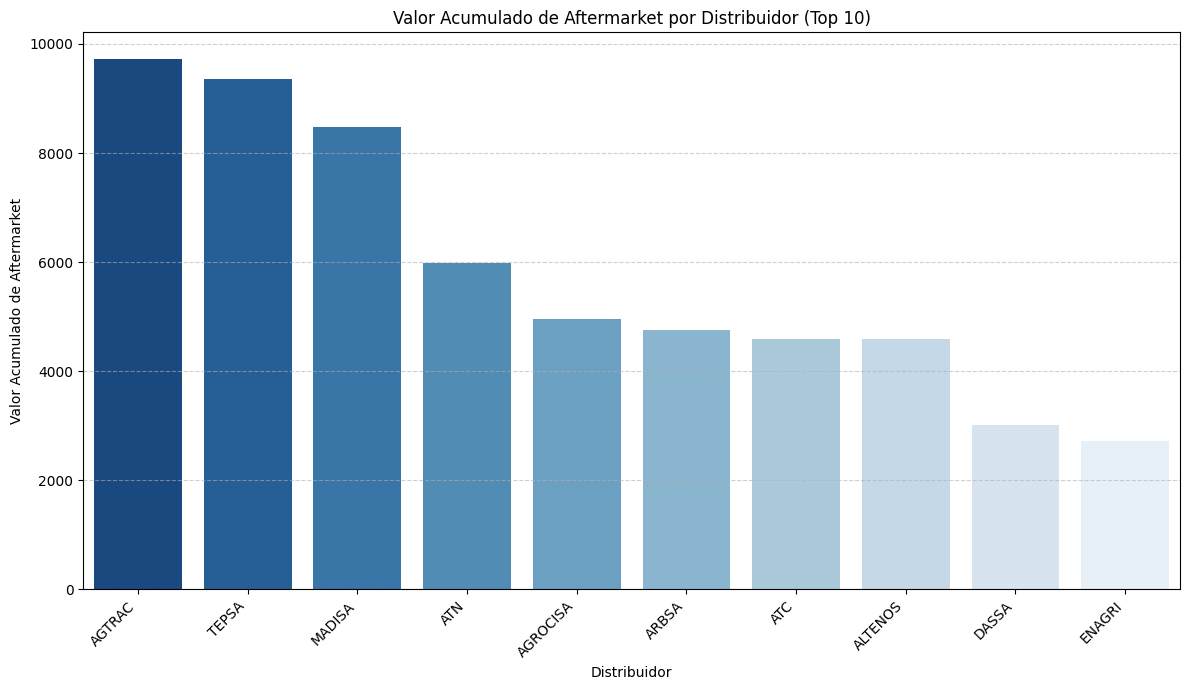

Tabla: Valor Acumulado de Aftermarket por Distribuidor


,DISTRIBUIDOR,valor_acumulado_aftermarket
0,AGTRAC,9726.0
1,TEPSA,9358.0
2,MADISA,8481.0
3,ATN,5988.0
4,AGROCISA,4951.0
5,ARBSA,4751.0
6,ATC,4594.0
7,ALTENOS,4590.0
8,DASSA,3018.0
9,ENAGRI,2717.0


In [ ]:
# Juntar df_monetization con la ALIAS-DISTRIBUIDOR
alias_dist_map = mantenimientos[['ALIAS', 'DISTRIBUIDOR']].drop_duplicates()
df_monetization_with_dist = pd.merge(df_monetization, alias_dist_map, on='ALIAS', how='left')

# Agrupar el total de valor aftermarket por distribuidor
dist_total_aftermarket = df_monetization_with_dist.groupby('DISTRIBUIDOR')['valor_acumulado_aftermarket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=dist_total_aftermarket.index, y=dist_total_aftermarket.values, palette='Blues_r')
plt.title('Valor Acumulado de Aftermarket por Distribuidor (Top 10)')
plt.xlabel('Distribuidor')
plt.ylabel('Valor Acumulado de Aftermarket')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Tabla: Valor Acumulado de Aftermarket por Distribuidor")
display(dist_total_aftermarket.reset_index())

### **KPIs y Tablas para el Dashboard de Proyección**

Para el tablero de **Proyección**, pensamos en incluir los siguientes KPIs y tablas del análisis de monetización y riesgo:

*   **Score de Oportunidad de Monetización (promedio o top N)**: Un KPI que muestre el promedio del `score_oportunidad` a nivel global o el top de unidades con mayor score.
    *   **Tabla Recomendada**: "Top 10 Unidades con Mayor Oportunidad de Monetización" (similar a la visualización generada, pero en formato de tabla para tener más detalle).
*   **Distribución del Score de Oportunidad**: Un gráfico (histograma o densidad) que muestre cómo se distribuye el `score_oportunidad` entre las unidades. Esto ayuda a visualizar el potencial general.
*   **Unidades en "Alerta Roja"**: Conteo de unidades identificadas como "Alerta Roja" (Estatus 'Pendiente' o 'CerradaFuera' con `overdue_risk` alto y `SEVERITY_LEVEL` 'High').
    *   **Tabla Recomendada**: "Listado de Unidades en Alerta Roja" con detalles como `ALIAS`, `DISTRIBUIDOR`, `ESTATUS`, `overdue_risk` y `SEVERITY_LEVEL`.

### **KPIs y Tablas para el Dashboard de Monetización**

Para el tablero de **Monetización**, los KPIs y tablas deben enfocarse en el potencial de negocio y la eficiencia:

*   **Proporción de Servicios 'Pendiente' o 'CerradaFuera'**: KPI principal con su Intervalo de Confianza (95%) para evaluar la "fuga latente".
    *   **Tabla Recomendada**: "Análisis de Proporciones de Estatus de Servicio" mostrando las proporciones de 'Pendiente', 'CerradaFuera' y 'Cerrada', junto con el IC para el grupo de alto riesgo.
*   **Valor Acumulado de Aftermarket (Total y por Distribuidor)**: KPI que muestre el valor total de Aftermarket. Desglosar por distribuidor es clave.
    *   **Tabla Recomendada**: "Valor Acumulado de Aftermarket por Distribuidor" (top N distribuidores), ya generada y validada.
*   **Frecuencia de Servicio vs. Valor Aftermarket**: Relación entre la `frecuencia_servicio` y `valor_acumulado_aftermarket` para identificar patrones.
    *   **Tabla Recomendada**: "Unidades con Mayor Frecuencia de Servicio y Valor Aftermarket" (listado detallado de unidades con ambos valores).
*   **Predicción de Oportunidad Alta de Monetización (XGBoost)**: KPI que muestre el AUC del modelo predictivo de oportunidad alta.
    *   **Tabla Recomendada**: "Unidades con Predicción de Alta Oportunidad de Monetización" (listado de `ALIAS` y su probabilidad predicha `y_pred_proba_monetization`).

### **KPIs y Tablas para el Dashboard de Distribuidores**

Para el tablero de **Distribuidores**, el enfoque debe ser el rendimiento y el riesgo asociado a cada distribuidor:

*   **Riesgo Promedio de Unidades por Distribuidor**: KPI que muestre el `avg_overdue_risk` promedio por distribuidor.
    *   **Tabla Recomendada**: "Top N Distribuidores por Riesgo Promedio de Unidades" (con el `avg_overdue_risk` y conteo de unidades).
*   **Número de Unidades en 'Alerta Roja' por Distribuidor**: KPI que destaque a los distribuidores con la mayor cantidad de unidades críticas.
    *   **Tabla Recomendada**: "Top N Distribuidores con Unidades en Alerta Roja" (con el conteo y porcentaje del total de su flota, si disponible).
*   **Valor Acumulado de Aftermarket por Distribuidor**: El mismo KPI que en monetización, pero con un enfoque en el rendimiento del distribuidor.
    *   **Tabla Recomendada**: "Ranking de Distribuidores por Valor Acumulado de Aftermarket" (ya generada y validada).
*   **Clusters de Riesgo por Distribuidor**: Un análisis de cómo se distribuyen los clusters de riesgo (obtenidos por K-Means) entre los distribuidores, para identificar cuáles manejan más unidades en clusters de alto riesgo.
    *   **Tabla Recomendada**: "Distribución de Clusters de Riesgo por Distribuidor" (conteo de unidades por cluster para cada distribuidor).